In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
# matplotlib.use("Agg") #figures are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [153]:
#DATA DESCRIPTIONS

### Data Type
# ARMBE: ARM Best Estimate Data Products

### Link
# https://armgov.svcs.arm.gov/data/science-data-products/vaps/armbe

### Summary
# This data product, formerly known as the Climate Modeling Best Estimate (CMBE) data set, 
# assembles a best estimate of cloud, radiation, and atmospheric quantities, 
# and surface/land properties that are both well observed by ARM
# and commonly used in model evaluation into one single data set. 
# For over two decades, most of these quantities have been measured by ARM ground-based instruments, 
# including cloud radars, micropulse lidars (MPLs), laser ceilometers, microwave radiometers (MWRs), 
# and solar and infrared radiation stations (SIRSs).

### Temporal Coverage
# Begin datetime	2022-05-25 00:00:00
# End datetime	2021-10-01 00:30:00

### Spatial Coverage
# Located at TRACER ARM M1 Facility at (29.67N, 95.059W)

In [8]:
################################################################################

In [20]:
#SET UP DIRECTORIES
Campaign="TRACER"
DataType="ARMBE_Atmosphere"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign=Campaign,
                     DataType=DataType,
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"):
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    Data_Directory = os.path.join(BaseDir, Campaign, DataType)
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = ListFiles(Data_Directory)
    return Data_Directory, FileList

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER 



In [16]:
#READING DATA FUNCTIONS
###################################

In [24]:
import xarray as xr
def GetData(Data_Directory, FileList, index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    # print(f"Downloading File:\n {DataFile}","\n")
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC, DataFile

In [65]:
import pandas as pd
def subset_time(data, start_date, end_date, buffer="1D", time_name="time"):
    """
    Subset an xarray Dataset/DataArray between two dates with optional buffer.

    Parameters
    ----------
    data : xr.Dataset or xr.DataArray
        Input data with a time coordinate.
    start_date : str or datetime-like
        Start of range (e.g., "2022-06-30").
    end_date : str or datetime-like
        End of range (e.g., "2022-07-03").
    buffer : str or pd.Timedelta, optional
        Extra padding before/after range (default "1D", e.g., "6H").
    time_name : str, optional
        Name of time dimension (default "time").

    Returns
    -------
    xr.Dataset or xr.DataArray
        Subset of the input data in the requested time window.
    """
    start = pd.to_datetime(start_date) - pd.Timedelta(buffer)
    end   = pd.to_datetime(end_date)   + pd.Timedelta(buffer)
    return data.sel({time_name: slice(start, end)})
    
def subset_until_date(data, target_date, time_name="time"):
    """
    Select all data up to and including the first timestamp 
    on the given target_date.

    Parameters
    ----------
    data : xr.Dataset or xr.DataArray
        Input data with a time coordinate.
    target_date : str or np.datetime64
        Date (YYYY-MM-DD) to stop at.
    time_name : str, optional
        Name of the time dimension. Default is 'time'.

    Returns
    -------
    xr.Dataset or xr.DataArray
        Subset of the data up to the first timestamp on target_date.
    """
    times = pd.to_datetime(data[time_name].values)
    target_date = pd.to_datetime(target_date).date()

    # Find first index where the date matches
    idx = np.where(times.date == target_date)[0][0]

    # Slice everything up to and including that index
    return data.isel({time_name: slice(0, idx+1)})

In [ ]:
#READING DATA
###################################

In [154]:
#GETTING DATA
[Data_Directory, FileList] = GetDataDirectory()
[DataNC, DataFile] = GetData(Data_Directory, FileList, index=1) #index 0 = 2021, index 1 = 2022

#SUBSETTING DATA TIME
start_date="2022-06-30"
end_date="2022-07-03"

DataNC_subset = subset_time(DataNC, start_date, end_date)
DataNC_subset = subset_until_date(DataNC_subset, end_date)

Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/ARMBE_Atmosphere 



In [111]:
DataNC_subset.data_vars

Data variables:
    base_time                  datetime64[ns] 8B ...
    time_offset                (time) datetime64[ns] 776B ...
    time_bounds                (time, bound) datetime64[ns] 2kB ...
    pressure_bounds            (pressure, bound) float32 296B ...
    height_bounds              (height, bound) float32 4kB ...
    height_10m                 float32 4B ...
    height_2m                  float32 4B ...
    u_wind_sfc                 (time) float32 388B ...
    v_wind_sfc                 (time) float32 388B ...
    relative_humidity_sfc      (time) float32 388B ...
    pressure_sfc               (time) float32 388B ...
    precip_rate_sfc            (time) float32 388B ...
    sensible_heat_flux_baebbr  (time) float32 388B ...
    latent_heat_flux_baebbr    (time) float32 388B ...
    temperature_sfc            (time) float32 388B ...
    sensible_heat_flux_qcecor  (time) float32 388B ...
    latent_heat_flux_qcecor    (time) float32 388B ...
    temperature_p             

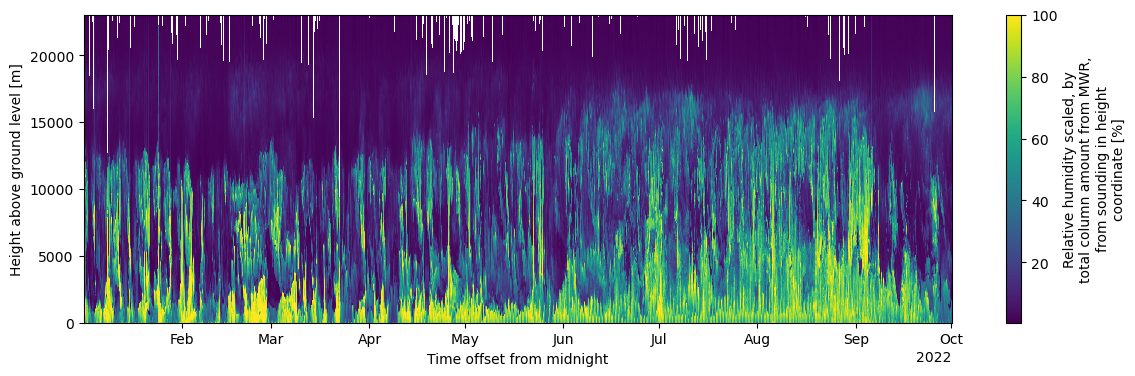

In [164]:
fig, ax = plt.subplots(figsize=(14, 4))
DataNC['relative_humidity_h'].T.dropna(dim="time", how="all").plot()

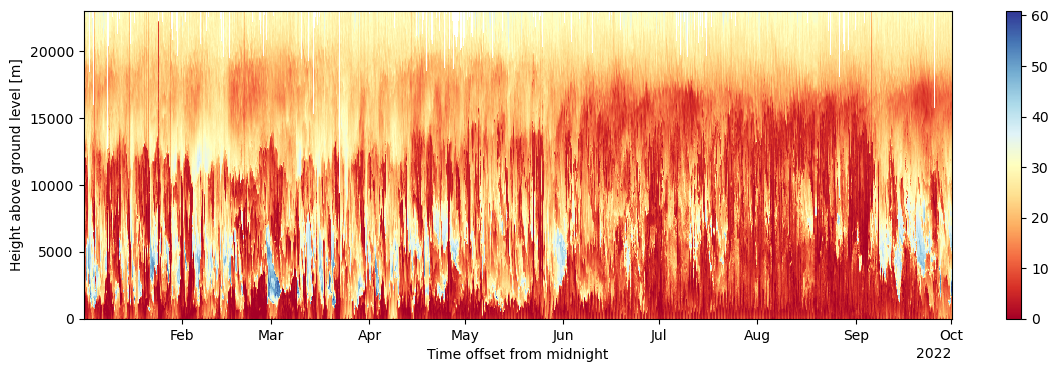

In [176]:
fig, ax = plt.subplots(figsize=(14, 4))

plot = ((DataNC['temperature_h'] - DataNC['dewpoint_h'])
        .T
        .dropna(dim="time", how="all")
        .plot(ax=ax, cmap="RdYlBu"))  # reversed colormap


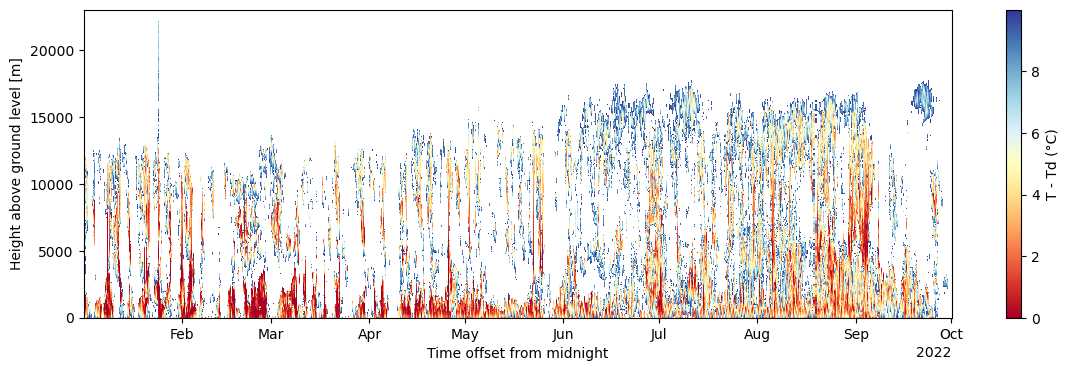

In [177]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))

hi = (DataNC['temperature_h'] - DataNC['dewpoint_h']).T.dropna(dim="time", how="all")

# Keep only values < 5, mask the rest
hi = hi.where(hi < 10)

# Plot
hi.plot(ax=ax, cmap="RdYlBu", cbar_kwargs={"label": "T - Td (°C)"})


In [ ]:
#PLOTTING DATA FUNCTIONS
###################################

In [105]:
def PlotVariable_TZ(variable):
    # DataNC_subset[variable].T.plot()
    DataNC_subset[variable].T.dropna(dim="time", how="all").plot()

In [117]:
#PLOTTING DATA
###################################

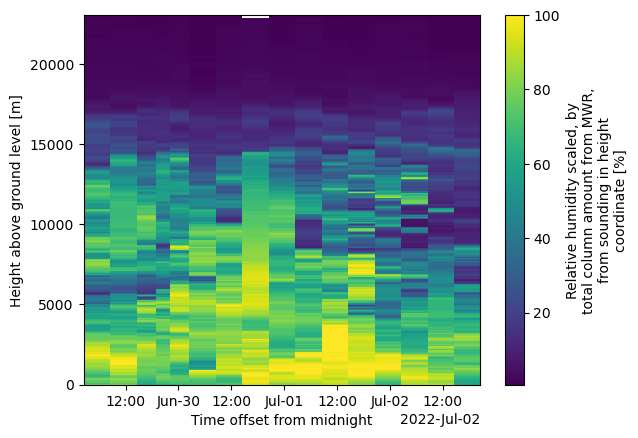

In [128]:
PlotVariable_TZ(variable='relative_humidity_h')

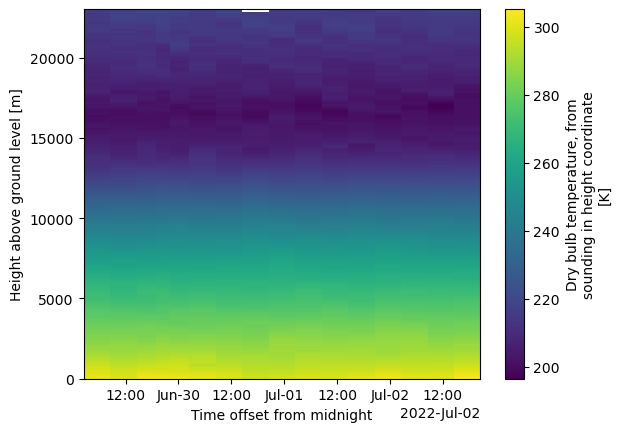

In [113]:
PlotVariable_TZ(variable='temperature_h')

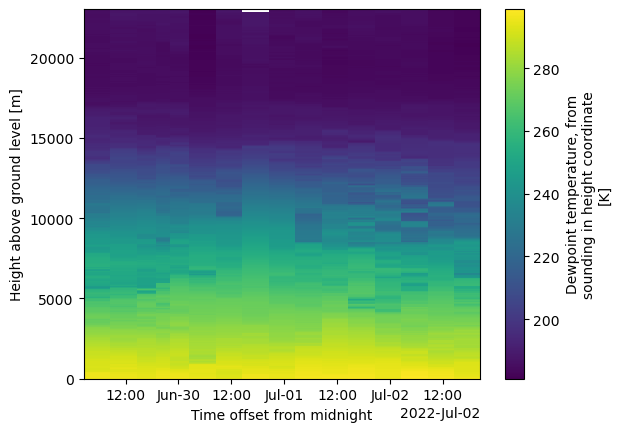

In [114]:
PlotVariable_TZ(variable='dewpoint_h')

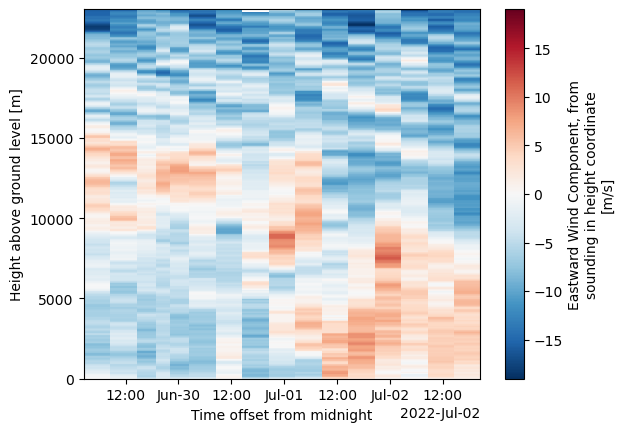

In [115]:
PlotVariable_TZ(variable='u_wind_h')

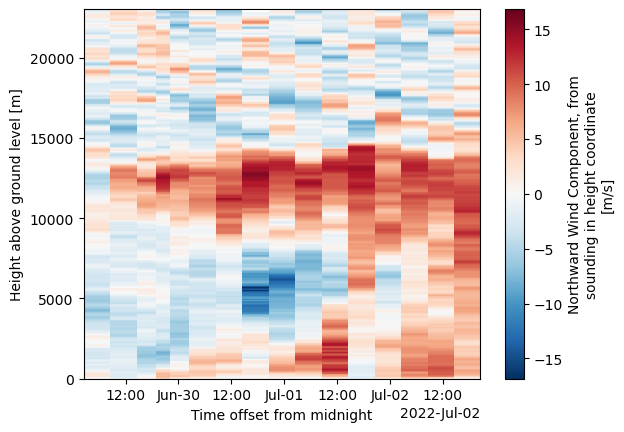

In [116]:
PlotVariable_TZ(variable='v_wind_h')

In [ ]:
#VAPOR CALCULATIONS

In [118]:
import numpy as np
import xarray as xr

def vapor_pressures_cc(temp_da, rh_da):
    """
    Calculate saturation vapor pressure (e_s) and actual vapor pressure (e)
    using the Clausius–Clapeyron equation.

    Parameters
    ----------
    temp_da : xr.DataArray
        Temperature in Kelvin.
    rh_da : xr.DataArray
        Relative humidity in percent (0–100).

    Returns
    -------
    e_s : xr.DataArray
        Saturation vapor pressure (Pa).
    e : xr.DataArray
        Actual vapor pressure (Pa).
    """
    # constants
    Lv = 2.5e6     # J/kg
    Rv = 461.0     # J/(kg*K)
    T0 = 273.15    # K
    es0 = 611.2    # Pa, reference at T0

    # saturation vapor pressure from Clausius–Clapeyron
    e_s = es0 * np.exp((Lv/Rv) * (1/T0 - 1/temp_da))

    # actual vapor pressure
    e = (rh_da/100.0) * e_s

    # add metadata
    e_s = e_s.rename("saturation_vapor_pressure").assign_attrs(units="Pa")
    e   = e.rename("vapor_pressure").assign_attrs(units="Pa")

    return e_s, e


In [124]:
T = DataNC_subset['temperature_h']          # Kelvin
RH = DataNC_subset['relative_humidity_h'] # percent

e_s, e = vapor_pressures_cc(T, RH)

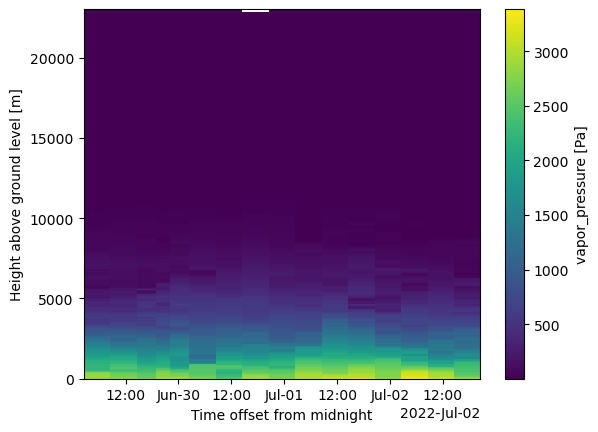

In [132]:
e.T.dropna(dim="time", how="all").plot()

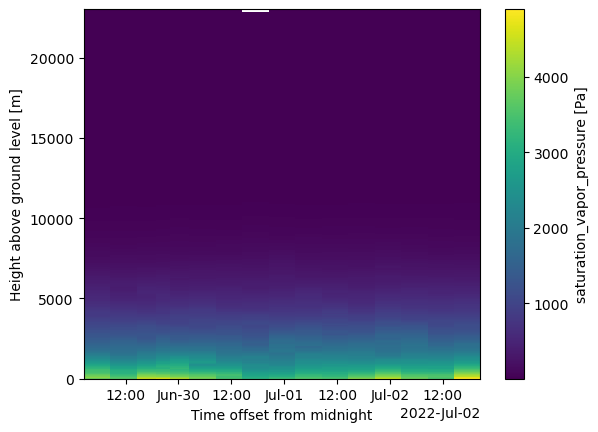

In [133]:
e_s.T.dropna(dim="time", how="all").plot()

In [139]:
import xarray as xr
import numpy as np

def vapor_to_specific_humidity(e_da, p_da):
    """
    Convert vapor pressure to specific humidity.

    Parameters
    ----------
    e_da : xr.DataArray
        Vapor pressure (Pa).
    p_da : xr.DataArray
        Ambient pressure (Pa).
    
    Returns
    -------
    qv : xr.DataArray
        Specific humidity (kg/kg).
    """
    eps = 0.622  # Rd/Rv
    qv = (eps * e_da) / (p_da - (1 - eps) * e_da)

    qv = qv.rename("specific_humidity").assign_attrs(units="kg/kg")
    return qv


In [140]:
import numpy as np
import xarray as xr

def hydrostatic_pressure_from_T(temp_h, psfc, height):
    """
    Compute hydrostatic pressure profile on height coordinates from 
    surface pressure and temperature, ignoring virtual temperature.

    Parameters
    ----------
    temp_h : xr.DataArray
        Temperature (K), dims (time, height).
    psfc : xr.DataArray
        Surface pressure (Pa or hPa), dims (time).
    height : xr.DataArray
        Height levels (m).

    Returns
    -------
    p_h : xr.DataArray
        Hydrostatic pressure profile (Pa), dims (time, height).
    """
    g = 9.81    # m/s^2
    Rd = 287.0  # J/(kg*K)

    # make sure surface pressure is in Pa
    if psfc.max() < 20000:
        psfc = psfc * 100.0

    # height grid
    z = height.values
    dz = np.diff(z)

    nt, nz = temp_h.shape
    p = np.zeros((nt, nz))
    p[:, 0] = psfc.values  # initialize with surface pressure

    # integrate upward
    for k in range(1, nz):
        # average layer temperature
        T_layer = 0.5 * (temp_h[:, k-1] + temp_h[:, k])
        p[:, k] = p[:, k-1] * np.exp(-g * dz[k-1] / (Rd * T_layer))

    # return as DataArray
    return xr.DataArray(
        p,
        coords=temp_h.coords,
        dims=temp_h.dims,
        name="pressure_h",
        attrs={"units": "Pa", "long_name": "Hydrostatic pressure from T"}
    )


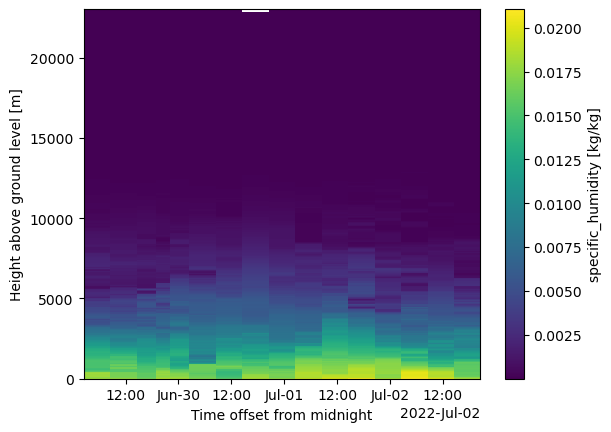

In [147]:
# Suppose you already computed e (Pa) from RH and T
e_s, e = vapor_pressures_cc(T, RH)

# Need total pressure from dataset
T_h = DataNC_subset['temperature_h']        # K  #(not using T_v)
psfc = DataNC_subset['pressure_sfc']        # hPa or Pa
height = DataNC_subset['height']            # m
p_h = hydrostatic_pressure_from_T(T_h, psfc, height)
p = p_h  # in Pa

qv = vapor_to_specific_humidity(e, p)
qv.T.dropna(dim="time", how="all").plot()
